In [3]:
# Data Mining Project — Preprocessing
# **Team member:** [Numele tău]  
# **Dataset:** [Numele datasetului]  
# **Source:** [URL sau cale]

In [4]:
# Load dataset pandas
# Citim CSV-ul cu read_csv() și afișăm primele rânduri.
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Inspecție generală describe / dtypes
# Verificăm statistici de bază și tipurile de date.
# shape și coloane
print(housing.shape)
print(housing.columns.tolist())
display(housing.describe()) # statistici descriptive
display(housing.dtypes) # tipuri de date



(20640, 10)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [6]:
# Valori lipsă (missing values) ~207 NaN
# De ce? Nu putem antrena un model cu NaN-uri. Imputăm cu mediana (mai robustă decât media față de outlieri).
# verificăm câte valori lipsă există
print(housing.isnull().sum())

# calculăm mediana și înlocuim NaN
median_bed = housing['total_bedrooms'].median()
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median_bed)

# confirmare
print(housing.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
# how many rows are at the cap?
cap = housing['median_house_value'].max()
n_capped = (housing['median_house_value'] == cap).sum()
print(f"Rows at cap ({cap}): {n_capped}")

# remove capped rows
housing_clean = housing[
    housing['median_house_value'] < cap
].copy()

print(f"Rows remaining: {len(housing_clean)}")

Rows at cap (500001.0): 965
Rows remaining: 19675


In [8]:
# Tipuri de date category
# Coloana ocean_proximity e text (object), dar reprezintă categorii finite. Convertim la category pentru eficiență și corectitudine.
housing_clean['ocean_proximity'] = \
    housing_clean['ocean_proximity'].astype('category')

print(housing_clean['ocean_proximity'].value_counts())
print(housing_clean['ocean_proximity'].dtype)

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64
category


In [9]:
# Separă coloana țintă (target) X și y
# Prețul casei (median_house_value) este ce vrem să prezicem — îl scoatem separat în y. Restul coloanelor devin features în X.
# y = ce vrem să prezicem (prețul)
y = housing_clean['median_house_value']

# X = toate celelalte coloane (features)
X = housing_clean.drop(columns=['median_house_value'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColoane X: {X.columns.tolist()}")

X shape: (19675, 9)
y shape: (19675,)

Coloane X: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [10]:
# One-hot encoding for ocean_proximity
# ML models cannot work with text. We convert ocean_proximity into numeric columns using get_dummies().
# drop_first=True removes one redundant column to avoid multicollinearity.

# check that ocean_proximity exists in X before encoding
print("Columns before encoding:", X.columns.tolist())

# one-hot encoding — works with both 'object' and 'category' dtype
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

print("Columns after encoding:", X.columns.tolist())
print(f"X shape after encoding: {X.shape}")

Columns before encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Columns after encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
X shape after encoding: (19675, 12)


In [11]:
# Train / Test split 80% / 20%
# Antrenăm modelul pe X_train / y_train, evaluăm pe X_test / y_test.
# random_state=42 asigură reproductibilitate.
# stratify=None pentru că y e continuu (regresie) — nu se poate stratifica
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (15740, 12)
X_test:  (3935, 12)
y_train: (15740,)
y_test:  (3935,)


In [12]:
# Normalizare cu StandardScaler — din Exercise 1 Solution & Exercise 2
# Features au scale-uri foarte diferite (ex. median_income 1-15 vs total_rooms 1-40000).
# StandardScaler scade media și împarte la deviația standard → toți în același range.
# IMPORTANT: fit_transform doar pe train, transform pe test — altfel modelul "vede" test data!
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform pe train: învață mean și std DIN TRAINING
X_train_scaled = scaler.fit_transform(X_train)

# doar transform pe test: aplică același mean/std — NU re-fit!
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("Mean (ar trebui ~0):", X_train_scaled.mean(axis=0).round(2))
print("Std (ar trebui ~1):", X_train_scaled.std(axis=0).round(2))

X_train_scaled shape: (15740, 12)
Mean (ar trebui ~0): [-0.  0. -0. -0.  0.  0. -0.  0.  0.  0. -0.  0.]
Std (ar trebui ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


y_train stats:
count     15740.0
mean     192191.0
std       97166.0
min       14999.0
25%      116700.0
50%      174100.0
75%      247600.0
max      500000.0
Name: median_house_value, dtype: float64

y_test stats:
count      3935.0
mean     193625.0
std       99868.0
min       14999.0
25%      116200.0
50%      171800.0
75%      251550.0
max      500000.0
Name: median_house_value, dtype: float64


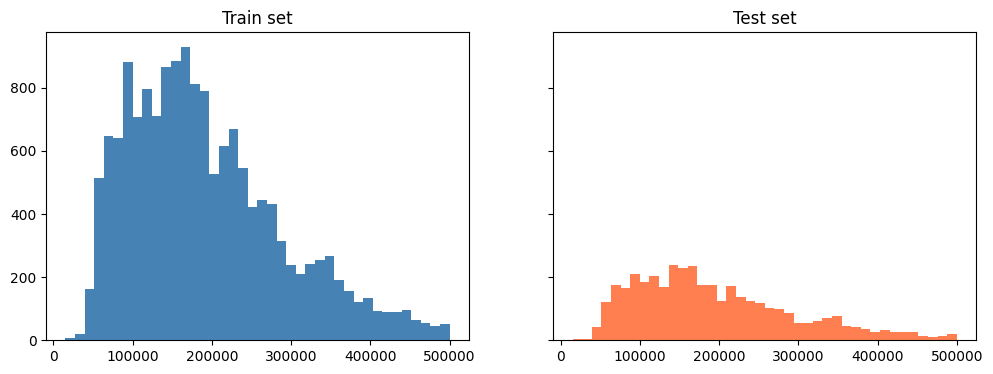

In [13]:
# Verificare finală a split-ului
# Verificăm că distribuția lui y e similară în train și test — nu vrem ca toate casele scumpe să ajungă doar în train.
# comparăm distribuțiile y_train vs y_test
print("y_train stats:")
print(y_train.describe().round(0))

print("\ny_test stats:")
print(y_test.describe().round(0))

# vizualizare side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax1.hist(y_train, bins=40, color='steelblue')
ax1.set_title('Train set')
ax2.hist(y_test, bins=40, color='coral')
ax2.set_title('Test set')
plt.show()

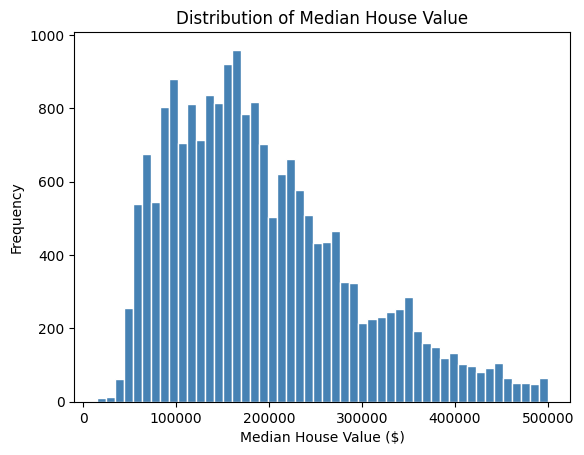

In [14]:
# Histogramă — distribuția valorilor caselor
# Analog cu histograma notelor din exercițiul de la clasă.
plt.hist(
    housing_clean['median_house_value'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

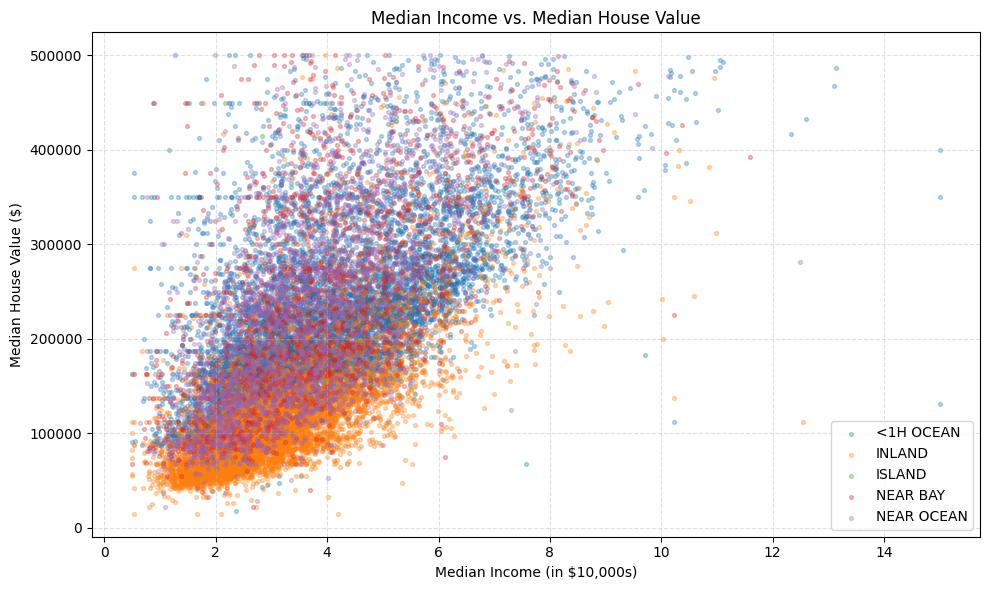

In [15]:
# Scatter plot — income vs. house value

plt.figure(figsize=(10, 6))

for name, group in housing_clean.groupby('ocean_proximity', observed=True):
    plt.scatter(
        group['median_income'],
        group['median_house_value'],
        label=name,
        alpha=0.3,
        s=8
    )

plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('Median House Value ($)')
plt.title('Median Income vs. Median House Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

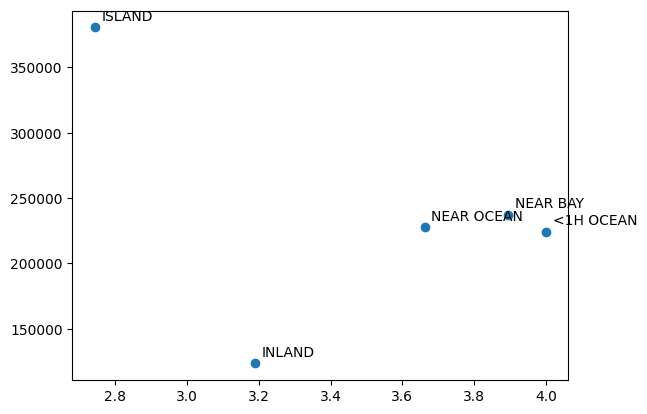

In [16]:
# Agregare pe grupuri groupby
# Analog cu agregarea pe student. Grupăm după ocean_proximity și calculăm media.
grouped = housing_clean.groupby('ocean_proximity', observed=True).mean(numeric_only=True)

# scatter pe date agregate
plt.scatter(
    grouped['median_income'],
    grouped['median_house_value']
)

# annotăm fiecare punct cu numele grupului
for name, row in grouped.iterrows():
    plt.annotate(name,
        (row['median_income'], row['median_house_value']),
        xytext=(5, 5), textcoords='offset points'
    )

plt.show()

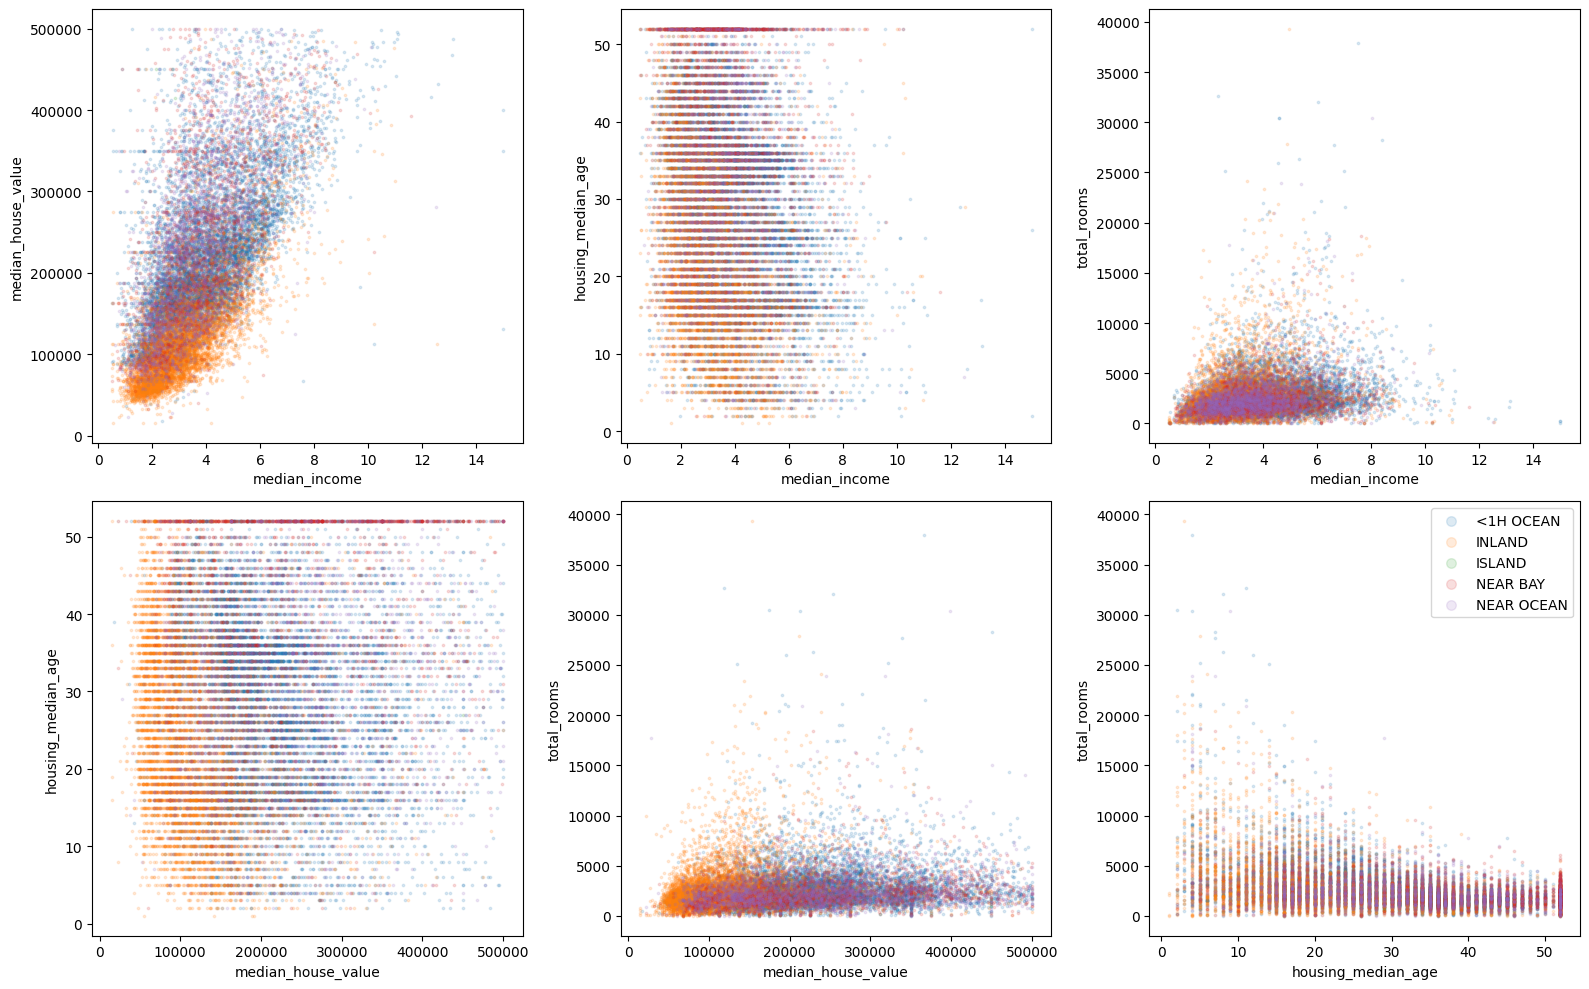

In [17]:
# Scatter matrix — toate combinațiile de features
# Analog cu Iris scatter matrix. Iterăm cu itertools.combinations și colorăm după ocean_proximity.
import itertools

features = [
    'median_income', 'median_house_value',
    'housing_median_age', 'total_rooms'
]
combinations = list(itertools.combinations(features, 2))

fig = plt.figure(figsize=(16, 10))

for i, combo in enumerate(combinations, 1):
    axs = fig.add_subplot(2, 3, i)
    for name, group in housing_clean.groupby('ocean_proximity', observed=True):
        axs.scatter(
            group[combo[0]], group[combo[1]],
            label=name, alpha=0.15, s=3
        )
    axs.set_xlabel(combo[0])
    axs.set_ylabel(combo[1])

plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

In [ ]:
# linear progression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_features = PolynomialFeatures(degree=2, include_bias=False).fit_transform()